# KNN Regression Analysis

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
# Import clean dataset 
df_model = pd.read_csv("../data/housing_clean.csv")
print(f"Shape: {df_model.shape}")
df_model

Shape: (21612, 22)


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
0,7129300520,221900.0,3,1.00,1180,5650,1.0,0,0,3,...,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,0,3,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,0,3,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,0,5,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,1954400510,510000.0,3,2.00,1680,8080,1.0,0,0,3,...,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21607,263000018,360000.0,3,2.50,1530,1131,3.0,0,0,3,...,0,2009,0,98103,47.6993,-122.346,1530,1509,2014,5
21608,6600060120,400000.0,4,2.50,2310,5813,2.0,0,0,3,...,0,2014,0,98146,47.5107,-122.362,1830,7200,2015,2
21609,1523300141,402101.0,2,0.75,1020,1350,2.0,0,0,3,...,0,2009,0,98144,47.5944,-122.299,1020,2007,2014,6
21610,291310100,400000.0,3,2.50,1600,2388,2.0,0,0,3,...,0,2004,0,98027,47.5345,-122.069,1410,1287,2015,1


In [3]:
df_model.dtypes

id                 int64
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
sale_year          int64
sale_month         int64
dtype: object

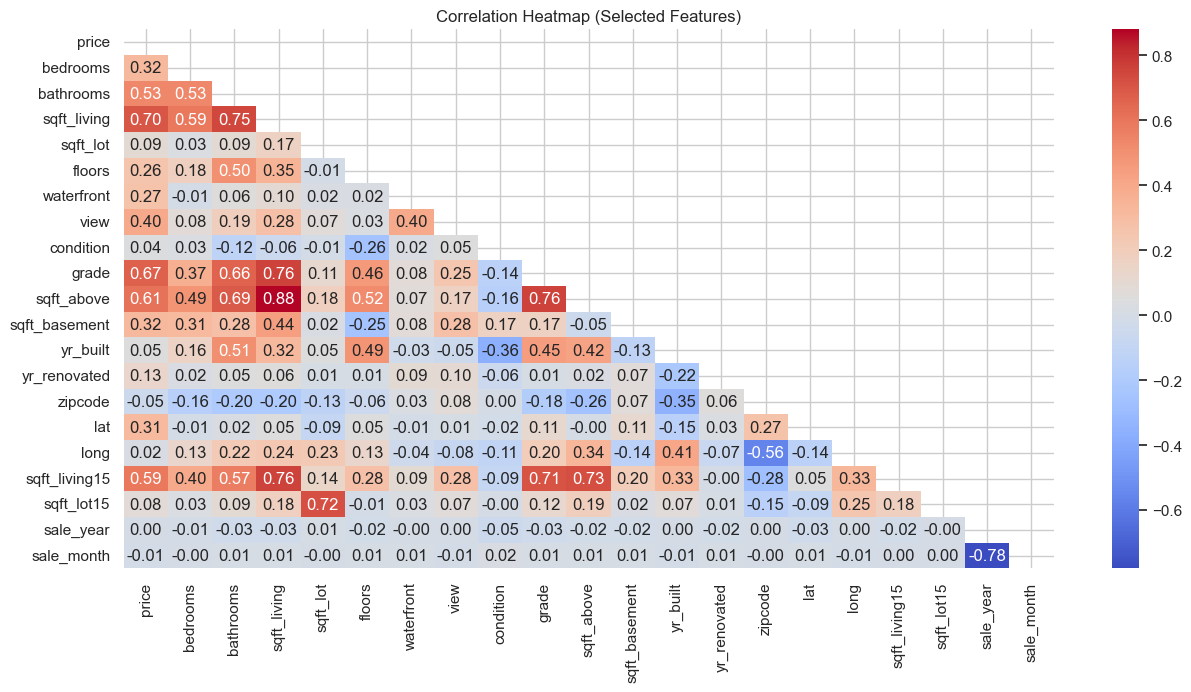

In [4]:
corr_cols = df_model.columns
corr_cols = corr_cols.drop(['id'])

correlation_matrix = round(df_model[corr_cols].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(15, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap (Selected Features)")
plt.show()

Base model, including the full dataset but the id.

In [5]:
target_col = "price"
feature_cols = [c for c in df_model.columns if c != target_col]

X = df_model[feature_cols].copy()
X = X.drop('id', axis = 1)
y = df_model[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
X.head(10)

X_train shape: (17289, 20)
X_test shape: (4323, 20)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2
5,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930,2014,5
6,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819,2014,6
7,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711,2015,1
8,3,1.00,1780,7470,1.0,0,0,3,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113,2015,4
9,3,2.50,1890,6560,2.0,0,0,3,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570,2015,3


In [6]:
# Scale the data
scaler = StandardScaler()

# Scale training set
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

# Scale testing set
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [7]:
# Default hyperparameter: n_neighbors = 5
knn = KNeighborsRegressor()

# Fit model
knn.fit(X_train_scaled, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled)
y_test_scaled_pred = knn.predict(X_test_scaled)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}')

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.861
Testing set R-squared: 0.765
Training set RMSE: 135085.7
Testing set RMSE: 187861.0
Training set MAE: 74315.9
Testing set MAE: 98216.4


To try to improve the data, features that have a correlation with price < 0.2 will be removed.

In [8]:
# Keep only the features that have a correlation with price > 0.2 (results from EDA)
X_train_scaled = X_train_scaled[['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 'view', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'sqft_living15']]
X_test_scaled = X_test_scaled[['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 'view', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'sqft_living15']]

In [9]:
X_train_scaled.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 'view',
       'grade', 'sqft_above', 'sqft_basement', 'lat', 'sqft_living15'],
      dtype='object')

In [10]:
# Fit model
knn.fit(X_train_scaled, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled)
y_test_scaled_pred = knn.predict(X_test_scaled)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}')

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.832
Testing set R-squared: 0.743
Training set RMSE: 148125.6
Testing set RMSE: 196446.5
Training set MAE: 82457.4
Testing set MAE: 104604.7


Results of both testing and training set worsened.

The next step is to remove features that have a correlation with price < 0.3.

In [11]:
# Keep only the features that have a correlation with price > 0.3 (results from EDA)
X_train_scaled = X_train_scaled[['bedrooms', 'bathrooms', 'sqft_living', 'view', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'sqft_living15']]
X_test_scaled = X_test_scaled[['bedrooms', 'bathrooms', 'sqft_living', 'view', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'sqft_living15']]

In [12]:
X_train_scaled.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'view', 'grade', 'sqft_above',
       'sqft_basement', 'lat', 'sqft_living15'],
      dtype='object')

In [13]:
# Fit model
knn.fit(X_train_scaled, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled)
y_test_scaled_pred = knn.predict(X_test_scaled)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}')

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.822
Testing set R-squared: 0.696
Training set RMSE: 152773.0
Testing set RMSE: 213450.5
Training set MAE: 84272.4
Testing set MAE: 108362.3


Results of both testing and training set worsened when compared with the previous 2 conditions.

The next step is to remove features that have a correlation with price < 0.5.

In [14]:
# Keep only the features that have a correlation with price > 0.5 (results from EDA)
X_train_scaled = X_train_scaled[['bathrooms', 'sqft_living', 'view', 'grade', 'sqft_above', 'sqft_living15']]
X_test_scaled = X_test_scaled[['bathrooms', 'sqft_living', 'view', 'grade', 'sqft_above', 'sqft_living15']]

In [15]:
# Fit model
knn.fit(X_train_scaled, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled)
y_test_scaled_pred = knn.predict(X_test_scaled)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}') 

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.741
Testing set R-squared: 0.581
Training set RMSE: 184098.8
Testing set RMSE: 250766.8
Training set MAE: 120798.2
Testing set MAE: 157063.2


Again, the removal of more features negatively impacted the performance of the model. Even though the correlation with the price is not strong, all features seem to impact the model's performance, so they will be kept and further feature engineering will be performed.

What if only the features with positive correlation are kept?

In [16]:
X_train_scaled.columns

Index(['bathrooms', 'sqft_living', 'view', 'grade', 'sqft_above',
       'sqft_living15'],
      dtype='object')

In [17]:
# Scale the data
scaler = StandardScaler()

# Scale training set
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

# Scale testing set
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [18]:
X_train_scaled = X_train_scaled[['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
                                 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
                                 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15']]
X_test_scaled = X_test_scaled[['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
                                 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
                                 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15']]

In [19]:
X_train_scaled.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [20]:
# Fit model
knn.fit(X_train_scaled, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled)
y_test_scaled_pred = knn.predict(X_test_scaled)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}') 

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.864
Testing set R-squared: 0.785
Training set RMSE: 133489.1
Testing set RMSE: 179484.3
Training set MAE: 73408.5
Testing set MAE: 95715.8


Keeping only the features with positive correlation improved the model performance and reduced overfitting.

Next, a binary system for 'yr_renovated' where 0 represents houses that were not renovated and 1 houses that were renovated will be tested.

In [21]:
df_model['yr_renovated'].value_counts()

yr_renovated
0       20698
2014       91
2013       37
2003       36
2005       35
        ...  
1951        1
1959        1
1948        1
1954        1
1944        1
Name: count, Length: 70, dtype: int64

In [22]:
# Binary classification of renovation, where 0 is not-renovated and 1 is renovated.
df_model["yr_renovated_binary"] = (df_model["yr_renovated"] > 0).astype(int)

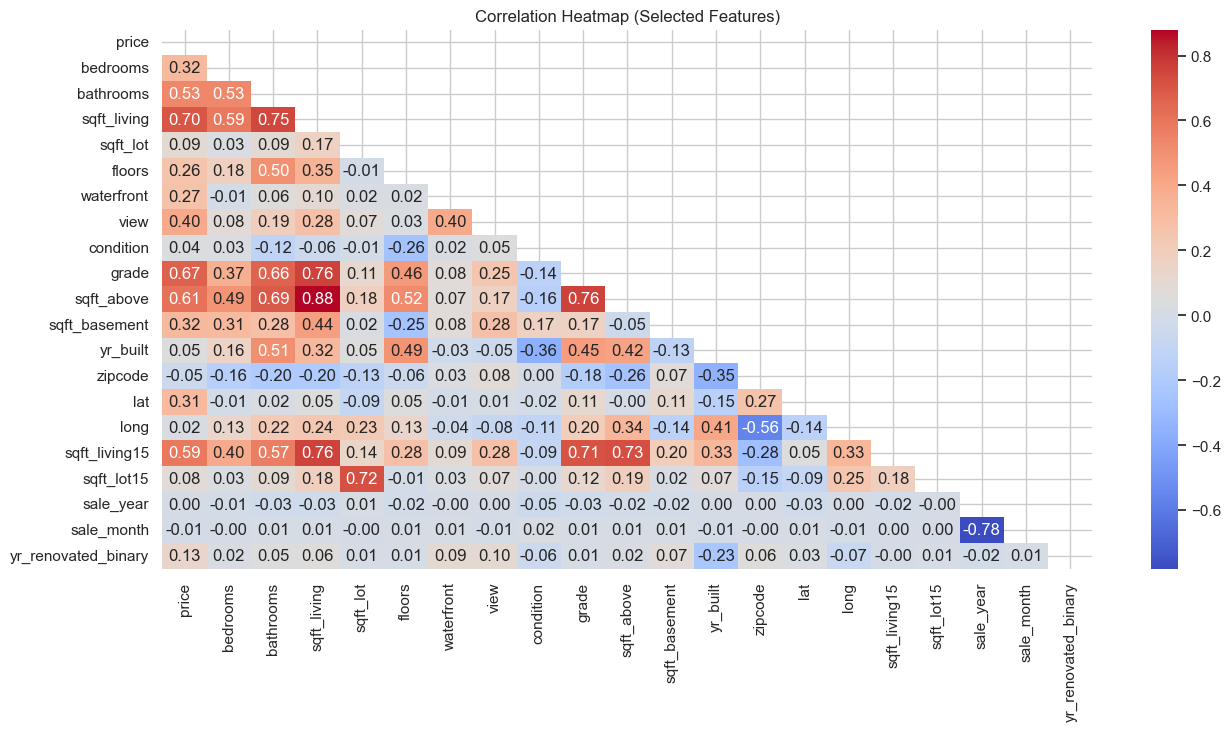

In [23]:
corr_cols = df_model.columns
corr_cols = corr_cols.drop(['id', 'yr_renovated'])

correlation_matrix = round(df_model[corr_cols].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(15, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap (Selected Features)")
plt.show()

In [24]:
feature_cols = [c for c in df_model.columns if c != target_col]
X = df_model[feature_cols].copy()
X = X.drop(['id', 'yr_renovated'], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
X.head(10)

X_train shape: (17289, 20)
X_test shape: (4323, 20)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,yr_renovated_binary
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,98178,47.5112,-122.257,1340,5650,2014,10,0
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,98125,47.7210,-122.319,1690,7639,2014,12,1
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,98028,47.7379,-122.233,2720,8062,2015,2,0
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,98136,47.5208,-122.393,1360,5000,2014,12,0
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,98074,47.6168,-122.045,1800,7503,2015,2,0
5,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,2001,98053,47.6561,-122.005,4760,101930,2014,5,0
6,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,98003,47.3097,-122.327,2238,6819,2014,6,0
7,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,98198,47.4095,-122.315,1650,9711,2015,1,0
8,3,1.00,1780,7470,1.0,0,0,3,7,1050,730,1960,98146,47.5123,-122.337,1780,8113,2015,4,0
9,3,2.50,1890,6560,2.0,0,0,3,7,1890,0,2003,98038,47.3684,-122.031,2390,7570,2015,3,0


In [25]:
# Scale training set
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

# Scale testing set
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [26]:
# Fit model
knn.fit(X_train_scaled, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled)
y_test_scaled_pred = knn.predict(X_test_scaled)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}')

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.861
Testing set R-squared: 0.765
Training set RMSE: 135085.7
Testing set RMSE: 187862.0
Training set MAE: 74315.9
Testing set MAE: 98221.9


Is the renovation period relevant for the importance of this feature?
The 'yr_renovated' will be transformed into a ternary system, where non-renovated houses are kept as 0, houses renovated from 2000 onwards are transformed to 1, and houses renovated earliear than 2000 are transformed to 2. This increase in granularity may help distinguish the importance when the renovation was performed.

In [27]:
# Group the 'yr-renovated' in different categories, where non-renovated houses are kept as 0
# houses renovated from 2000 onwards are transformed to 1
# houses renovated earliear than 2000 are transformed to 2
df_model["yr_renovated_ternary"] = np.select(
    [
        df_model['yr_renovated'].eq(0),
        df_model['yr_renovated'].between(2000, 2014, inclusive="both"),
    ],
    [
        0,
        1,
    ],
    default=2
)

df_model['yr_renovated_ternary'].value_counts().sort_index()

yr_renovated_ternary
0    20698
1      442
2      472
Name: count, dtype: int64

In [28]:
df_model.columns

Index(['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month',
       'yr_renovated_binary', 'yr_renovated_ternary'],
      dtype='object')

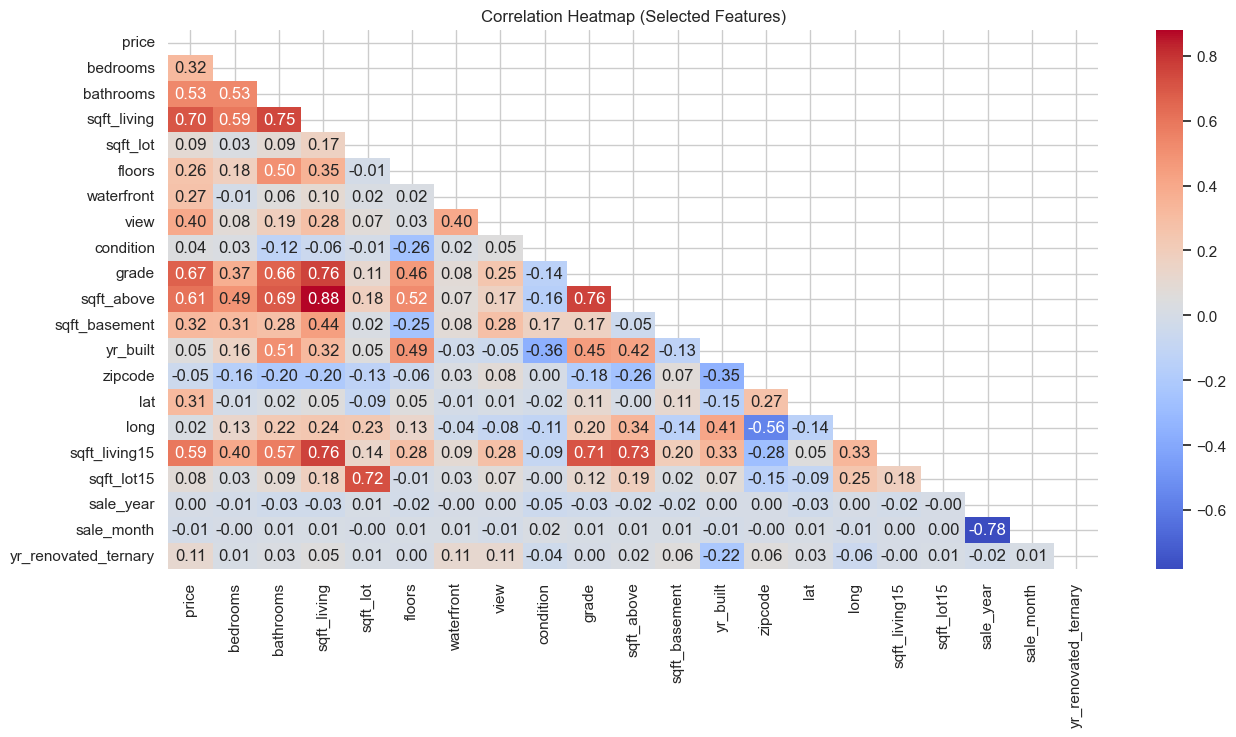

In [29]:
corr_cols = df_model.columns
corr_cols = corr_cols.drop(['id', 'yr_renovated', 'yr_renovated_binary'])

correlation_matrix = round(df_model[corr_cols].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(15, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap (Selected Features)")
plt.show()

In [30]:
feature_cols = [c for c in df_model.columns if c != target_col]
X = df_model[feature_cols].copy()
X = X.drop(['id', 'yr_renovated', 'yr_renovated_binary'], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
X.head(10)

X_train shape: (17289, 20)
X_test shape: (4323, 20)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,yr_renovated_ternary
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,98178,47.5112,-122.257,1340,5650,2014,10,0
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,98125,47.7210,-122.319,1690,7639,2014,12,2
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,98028,47.7379,-122.233,2720,8062,2015,2,0
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,98136,47.5208,-122.393,1360,5000,2014,12,0
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,98074,47.6168,-122.045,1800,7503,2015,2,0
5,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,2001,98053,47.6561,-122.005,4760,101930,2014,5,0
6,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,98003,47.3097,-122.327,2238,6819,2014,6,0
7,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,98198,47.4095,-122.315,1650,9711,2015,1,0
8,3,1.00,1780,7470,1.0,0,0,3,7,1050,730,1960,98146,47.5123,-122.337,1780,8113,2015,4,0
9,3,2.50,1890,6560,2.0,0,0,3,7,1890,0,2003,98038,47.3684,-122.031,2390,7570,2015,3,0


In [31]:
# Scale training set
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

# Scale testing set
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [32]:
# Fit model
knn.fit(X_train_scaled, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled)
y_test_scaled_pred = knn.predict(X_test_scaled)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}')

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.859
Testing set R-squared: 0.770
Training set RMSE: 135873.7
Testing set RMSE: 185634.6
Training set MAE: 74680.7
Testing set MAE: 97883.0


The ternary system allows for a better model performance, with slightly less overfitting than the binary system, due to the increase in testing set R-squared.

What if the granularity is increased, by splitting older renovations into 1944-1979 and 1980-1999?

In [33]:
# Group the 'yr-renovated' in different categories, where non-renovated houses are kept as 0
# houses renovated from 2000 onwards are transformed to 1
# houses renovated between 1980 and 1999 are transformed to 2
# houses renovated prior ti 1980 are transformed to 3
df_model["yr_renovated_quaternary"] = np.select(
    [
        df_model['yr_renovated'].eq(0),
        df_model['yr_renovated'].between(2000, 2014, inclusive="both"),
        df_model['yr_renovated'].between(1980, 1999, inclusive="both"),
    ],
    [
        0,
        1,
        2
    ],
    default=3
)

df_model['yr_renovated_quaternary'].value_counts().sort_index()

yr_renovated_quaternary
0    20698
1      442
2      334
3      138
Name: count, dtype: int64

In [34]:
feature_cols = [c for c in df_model.columns if c != target_col]
X = df_model[feature_cols].copy()
X = X.drop(['id', 'yr_renovated', 'yr_renovated_ternary', 'yr_renovated_ternary'], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
X.head(10)

X_train shape: (17289, 21)
X_test shape: (4323, 21)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,yr_built,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,yr_renovated_binary,yr_renovated_quaternary
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,...,1955,98178,47.5112,-122.257,1340,5650,2014,10,0,0
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,...,1951,98125,47.7210,-122.319,1690,7639,2014,12,1,2
2,2,1.00,770,10000,1.0,0,0,3,6,770,...,1933,98028,47.7379,-122.233,2720,8062,2015,2,0,0
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,...,1965,98136,47.5208,-122.393,1360,5000,2014,12,0,0
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,...,1987,98074,47.6168,-122.045,1800,7503,2015,2,0,0
5,4,4.50,5420,101930,1.0,0,0,3,11,3890,...,2001,98053,47.6561,-122.005,4760,101930,2014,5,0,0
6,3,2.25,1715,6819,2.0,0,0,3,7,1715,...,1995,98003,47.3097,-122.327,2238,6819,2014,6,0,0
7,3,1.50,1060,9711,1.0,0,0,3,7,1060,...,1963,98198,47.4095,-122.315,1650,9711,2015,1,0,0
8,3,1.00,1780,7470,1.0,0,0,3,7,1050,...,1960,98146,47.5123,-122.337,1780,8113,2015,4,0,0
9,3,2.50,1890,6560,2.0,0,0,3,7,1890,...,2003,98038,47.3684,-122.031,2390,7570,2015,3,0,0


In [35]:
# Scale training set
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

# Scale testing set
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [36]:
# Fit model
knn.fit(X_train_scaled, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled)
y_test_scaled_pred = knn.predict(X_test_scaled)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}')

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.860
Testing set R-squared: 0.763
Training set RMSE: 135463.7
Testing set RMSE: 188576.3
Training set MAE: 74668.1
Testing set MAE: 98370.1


The quaternary system did not improve model performance, so ther ternary classification of yr_renovation will be kept.

Now, the 'yr_built' will be converted to house age.

In [37]:
df_model['age'] = df_model['sale_year'] - df_model['yr_built']

In [38]:
df_model['age'].value_counts()

age
 9      473
 8      443
 11     433
 0      430
 10     428
       ... 
 113     28
 115     26
 81      23
 80      21
-1       12
Name: count, Length: 117, dtype: int64

In [39]:
df_model[df_model['age'] < 0]

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,yr_renovated_binary,yr_renovated_ternary,yr_renovated_quaternary,age
1763,1832100030,597326.0,4,4.00,3570,8250,2.0,0,0,3,...,47.5784,-122.226,2230,10000,2014,6,0,0,0,-1
2687,3076500830,385195.0,1,1.00,710,6000,1.5,0,0,3,...,47.5756,-122.316,1440,4800,2014,10,0,0,0,-1
7526,9520900210,614285.0,5,2.75,2730,6401,2.0,0,0,3,...,47.7685,-122.160,2520,6126,2014,12,0,0,0,-1
8039,1250200495,455000.0,2,1.50,1200,1259,2.0,0,0,3,...,47.6001,-122.298,1320,1852,2014,6,0,0,0,-1
14489,2770601530,500000.0,2,2.25,1570,1269,2.0,0,0,3,...,47.6514,-122.385,1570,6000,2014,8,0,0,0,-1
17097,9126100346,350000.0,3,2.00,1380,3600,3.0,0,0,3,...,47.6074,-122.305,1480,3600,2014,6,0,0,0,-1
19804,9126100765,455000.0,3,1.75,1320,1014,3.0,0,0,3,...,47.6047,-122.305,1380,1495,2014,8,0,0,0,-1
20769,9310300160,357000.0,5,2.50,2990,9240,2.0,0,0,3,...,47.7384,-122.348,1970,18110,2014,8,0,0,0,-1
20851,1257201420,595000.0,4,3.25,3730,4560,2.0,0,0,3,...,47.6725,-122.330,1800,4560,2014,7,0,0,0,-1
20962,6058600220,230000.0,3,1.50,1040,1264,2.0,0,0,3,...,47.5951,-122.301,1350,3000,2014,7,0,0,0,-1


There are 12 entries where the age is negative, indicating the year of construction was higher than the year the house was sold. This could indicate the was was sold still under construction or is a data entry error. Hence, only rows with age <=0 will be considered.

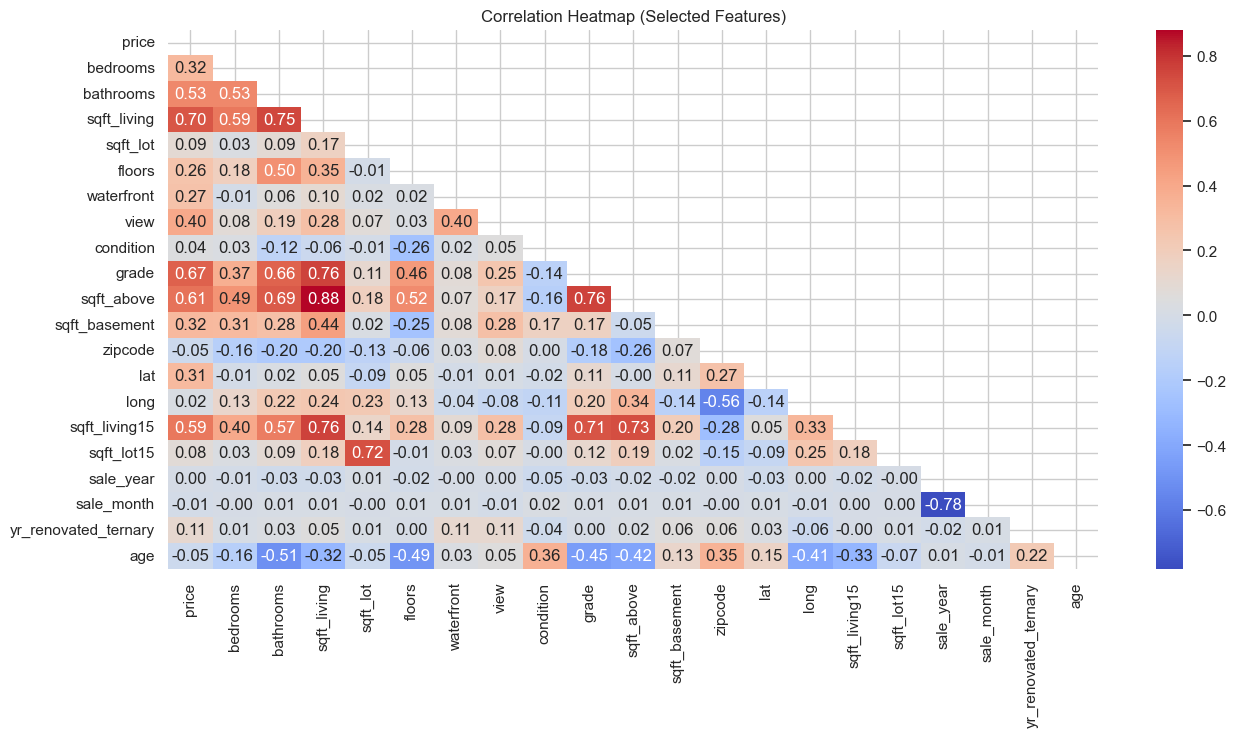

In [40]:
corr_cols = df_model.columns
corr_cols = corr_cols.drop(['id', 'yr_renovated', 'yr_renovated_binary', 'yr_renovated_quaternary', 'yr_built'])

correlation_matrix = round(df_model[corr_cols].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(15, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap (Selected Features)")
plt.show()

In [41]:
feature_cols = [c for c in df_model.columns if c != target_col]
df_model_dropped_age = df_model[df_model['age']>=0]
y = df_model_dropped_age['price']
X = df_model_dropped_age[feature_cols].copy()
X = X.drop(['id', 'yr_renovated', 'yr_renovated_binary', 'yr_renovated_quaternary', 'yr_built'], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
X.head(10)

X_train shape: (17280, 20)
X_test shape: (4320, 20)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,yr_renovated_ternary,age
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,98178,47.5112,-122.257,1340,5650,2014,10,0,59
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,98125,47.7210,-122.319,1690,7639,2014,12,2,63
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,98028,47.7379,-122.233,2720,8062,2015,2,0,82
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,98136,47.5208,-122.393,1360,5000,2014,12,0,49
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,98074,47.6168,-122.045,1800,7503,2015,2,0,28
5,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,98053,47.6561,-122.005,4760,101930,2014,5,0,13
6,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,98003,47.3097,-122.327,2238,6819,2014,6,0,19
7,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,98198,47.4095,-122.315,1650,9711,2015,1,0,52
8,3,1.00,1780,7470,1.0,0,0,3,7,1050,730,98146,47.5123,-122.337,1780,8113,2015,4,0,55
9,3,2.50,1890,6560,2.0,0,0,3,7,1890,0,98038,47.3684,-122.031,2390,7570,2015,3,0,12


In [42]:
# Scale training set
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

# Scale testing set
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [43]:
# Fit model
knn.fit(X_train_scaled, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled)
y_test_scaled_pred = knn.predict(X_test_scaled)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}')

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.850
Testing set R-squared: 0.771
Training set RMSE: 139849.0
Testing set RMSE: 186737.0
Training set MAE: 76546.3
Testing set MAE: 94051.9


In [44]:
X_train_scaled.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,yr_renovated_ternary,age
17610,-0.407513,-0.473758,-0.840149,-0.056085,-0.912953,-0.08467,-0.304852,-0.632697,-0.561784,-0.576581,-0.661692,-0.357040,-0.661698,1.019991,-0.288674,0.027421,-0.697736,-0.173889,-0.200017,-0.761888
16967,-0.407513,-0.798479,-1.157247,-0.149741,-0.912953,-0.08467,-0.304852,-0.632697,-0.561784,-1.048152,-0.434703,0.688512,0.968508,-0.618647,-0.537856,-0.178725,-0.697736,-0.173889,-0.200017,1.384505
17232,-0.407513,-1.447921,-0.807346,0.016487,-0.912953,-0.08467,-0.304852,0.898321,-1.413480,-0.540306,-0.661692,-0.674440,-1.725128,0.502153,-0.977589,-0.109517,-0.697736,-0.494745,-0.200017,-0.250842
17884,0.694494,-0.798479,0.515718,-0.278893,0.011069,-0.08467,-0.304852,0.898321,-0.561784,-0.032460,1.131523,0.688512,0.868021,-0.739240,-0.215385,-0.324175,-0.697736,1.109532,-0.200017,1.520784
7230,1.796500,0.500405,-0.096609,-0.206576,0.935091,-0.08467,-0.304852,0.898321,-0.561784,0.245646,-0.661692,-0.823805,1.121770,0.338999,0.004481,-0.207593,-0.697736,1.751242,-0.200017,-0.114563


This approach reduced the overfitting of the model.

In [45]:
X_train_scaled_dropped = X_train_scaled.drop('sale_year', axis=1)
X_test_scaled_dropped = X_test_scaled.drop('sale_year', axis=1)

knn = KNeighborsRegressor()

# Fit model
knn.fit(X_train_scaled_dropped, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled_dropped)
y_test_scaled_pred = knn.predict(X_test_scaled_dropped)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}')

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.855
Testing set R-squared: 0.773
Training set RMSE: 137567.6
Testing set RMSE: 186085.6
Training set MAE: 75115.2
Testing set MAE: 93014.9


In [46]:
X_train_scaled_dropped = X_train_scaled_dropped.drop('sale_month', axis=1)
X_test_scaled_dropped = X_test_scaled_dropped.drop('sale_month', axis=1)

knn = KNeighborsRegressor()

# Fit model
knn.fit(X_train_scaled_dropped, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled_dropped)
y_test_scaled_pred = knn.predict(X_test_scaled_dropped)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}')

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.861
Testing set R-squared: 0.780
Training set RMSE: 134660.7
Testing set RMSE: 182873.5
Training set MAE: 72422.9
Testing set MAE: 89501.8


In [47]:
"""
X_train_scaled_dropped = X_train_scaled_dropped.drop('zipcode', axis=1)
X_test_scaled_dropped = X_test_scaled_dropped.drop('zipcode', axis=1)

knn = KNeighborsRegressor()

# Fit model
knn.fit(X_train_scaled_dropped, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled_dropped)
y_test_scaled_pred = knn.predict(X_test_scaled_dropped)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}')

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')
"""

"\nX_train_scaled_dropped = X_train_scaled_dropped.drop('zipcode', axis=1)\nX_test_scaled_dropped = X_test_scaled_dropped.drop('zipcode', axis=1)\n\nknn = KNeighborsRegressor()\n\n# Fit model\nknn.fit(X_train_scaled_dropped, y_train)\n\n# Evaluate our fit model\ny_train_scaled_pred = knn.predict(X_train_scaled_dropped)\ny_test_scaled_pred = knn.predict(X_test_scaled_dropped)\n\n# Calculate R-squared for training and testing sets\nprint(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')\nprint(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')\n\n# Calculate RMSE for training and testing sets \nprint(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')\nprint(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}')\n\n# Calculate MAE for training and testing sets\nprint(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')\nprint(f'Testing set MAE: {mean_absolute

The removal of sale-year and sale_month improve the model's performance, however removing 'zipcode' worsens it.

Then, a GridSearchCV will be performed to tune the hyperparameter k.

In [48]:
# Hyperparameter tuning
grid = GridSearchCV(knn, 
                    {'n_neighbors': range(1,21)}, 
                    cv=5, 
                    scoring='neg_root_mean_squared_error')

grid.fit(X_train_scaled_dropped, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'n_neighbors': 9}
-167156.15659620558


The hyperparameter tuning yielded 9 as the best k value.

In [49]:
knn = KNeighborsRegressor(n_neighbors = 9)

# Fit model
knn.fit(X_train_scaled_dropped, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled_dropped)
y_test_scaled_pred = knn.predict(X_test_scaled_dropped)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}') #ou então RMSE

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.835
Testing set R-squared: 0.776
Training set RMSE: 146647.0
Testing set RMSE: 184616.3
Training set MAE: 78380.8
Testing set MAE: 89140.7


Using k = 9, the overfitting was reduced due to the decrease in R-squared from the training set.

Let's evaluate if changing the distance metric from Euclidian to Manhattan distance improves the model.

In [50]:
# Define hyperparameter and change to manhattan distance
knn = KNeighborsRegressor(n_neighbors = 9, p=1)

# Fit model
knn.fit(X_train_scaled_dropped, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled_dropped)
y_test_scaled_pred = knn.predict(X_test_scaled_dropped)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}') #ou então RMSE

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.856
Testing set R-squared: 0.805
Training set RMSE: 137090.1
Testing set RMSE: 172178.6
Training set MAE: 73093.7
Testing set MAE: 84273.9


In [51]:
# Define hyperparameter and change to manhattan distance
knn = KNeighborsRegressor(n_neighbors = 5, p=1)

# Fit model
knn.fit(X_train_scaled_dropped, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled_dropped)
y_test_scaled_pred = knn.predict(X_test_scaled_dropped)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}') #ou então RMSE

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.878
Testing set R-squared: 0.797
Training set RMSE: 126205.9
Testing set RMSE: 175844.8
Training set MAE: 67639.6
Testing set MAE: 85517.6


Changing the distance metric to Manhattan Distance improves the model performance by reducing overfitting by increasing the testing set R-squared. A higher k value improves the metrics from the testing set while a lower k values improves the metric from the training set, increasing the overfitting.

The best KNNRegressor model includes the following columns:

In [52]:
X_train_scaled_dropped.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'zipcode', 'lat', 'long', 'sqft_living15',
       'sqft_lot15', 'yr_renovated_ternary', 'age'],
      dtype='object')

And has the following statistical metrics:

In [53]:
# Define hyperparameter and change to manhattan distance
knn = KNeighborsRegressor(n_neighbors = 9, p=1)

# Fit model
knn.fit(X_train_scaled_dropped, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled_dropped)
y_test_scaled_pred = knn.predict(X_test_scaled_dropped)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}') #ou então RMSE

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.856
Testing set R-squared: 0.805
Training set RMSE: 137090.1
Testing set RMSE: 172178.6
Training set MAE: 73093.7
Testing set MAE: 84273.9


This model explains 85.6% of training price variation and 80.5% testing price variation, without overfitting.